# EDA 17: Model Master (Modern-Schema ID Resolution)

## Purpose

`17_Model.csv` is not present in `learn/v4`'s notebook set — it is a new acquisition, added to
`data/augmented/` specifically because AZ's delivery is not release-coherent.
`docs/PROJECT_ARCHITECTURE.md` §2 names the problem directly: file 9 (`9_DepMap_sample_info.csv`)
carries the **legacy** DepMap catalogue schema (`DepMap_ID`, `lineage`, `primary_disease`, retired
after 22Q1), while files 5, 8, 15, 16 use the **modern** schema (`ModelID`, `OncotreeLineage`,
`IsDefaultEntryForMC`). This file is current-release model metadata and is what root `_.md`
describes as resolving **286 orphan `ModelID`s** — this notebook measures that resolution directly
rather than taking the claimed number on faith.

**Source, release, grain:** current-release DepMap model metadata (see
`docs/reference/DOWNLOAD_STEPS.md` for acquisition). One row per `ModelID`.

## Questions this notebook must answer

1. Is `ModelID` unique, and how completely populated are the key identity/context columns?
2. How many `ModelID`s here do **not** appear in file 9's legacy `DepMap_ID` set — the orphans this
   file exists to resolve — and does the count match the ~286 claimed in root `_.md`?
3. Does the modern `OncotreeLineage` taxonomy diverge structurally from file 9's legacy `lineage`
   column for the models present in both?
4. How completely does this file cross-reference external identifiers (RRID, Sanger, COSMIC) that
   files 5/8/15/16 may need?

**Interpretation rule:** this is identity/context metadata, not a measurement — it has no
`measured`/`measured_absent`/`not_assayed` states of its own. Its role is purely to make every
modern-schema primary file (5, 8, 15, 16) joinable to models that file 9 alone cannot resolve.

## Column dictionary (selected)

| Column | Meaning | Notes |
|---|---|---|
| `ModelID` | modern DepMap key | same identifier space as files 5/8/15/16 |
| `RRID` | Cellosaurus accession | bridges to file 7, same field name as file 9 |
| `OncotreeLineage`, `OncotreePrimaryDisease`, `OncotreeSubtype` | modern cancer taxonomy | compare against file 9's legacy `lineage`/`primary_disease` |
| `CCLEName` | legacy CCLE identifier | equivalent to file 9's `CCLE_Name` |
| `SangerModelID`, `COSMICID`, `WTSIMasterCellID` | external cross-references | |
| `PatientID`, `Age`, `Sex`, `PrimaryOrMetastasis` | patient/sample context | modern equivalents of file 9's clinical metadata |

## 1. Basic data contract and schema audit

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
AUGMENTED = ROOT / 'data' / 'augmented'
NOMENCLATURE = ROOT / 'data' / 'raw' / 'nomenclature'

In [2]:
df = pd.read_csv(AUGMENTED / 'nomenclature' / '17_Model.csv')
print(f"Rows                : {len(df)}")
print(f"Unique ModelID      : {df['ModelID'].nunique()}")
pct_missing = df.isnull().mean().sort_values(ascending=False) * 100
pct_missing[pct_missing < 50].head(15)

Rows                : 2154
Unique ModelID      : 2154


CatalogNumber            47.168059
SangerModelID            43.361188
FormulationID            20.612813
SerumFreeMedia           20.612813
OnboardedMedia           20.612813
Age                      20.148561
ModelAvailableInDbgap    19.498607
PrimaryOrMetastasis      16.202414
OncotreeCode             10.492108
RRID                      7.335190
CCLEName                  5.756732
SourceType                1.671309
Sex                       1.067781
SampleCollectionSite      0.649954
OncotreeLineage           0.603528
dtype: float64

### Why this EDA check matters

Confirms `ModelID` is a clean primary key before it is trusted as the resolution table for every
other modern-schema file, and gives the real completeness of the columns most likely to be used
(identity, lineage, cross-references) rather than the many sparse clinical-detail columns.

## 2. Legacy vs. modern schema — orphan resolution

In [3]:
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['DepMap_ID', 'lineage'])
legacy_ids = set(df9['DepMap_ID'].dropna())
modern_ids = set(df['ModelID'].dropna())

orphans = modern_ids - legacy_ids
missing_from_modern = legacy_ids - modern_ids
overlap = modern_ids & legacy_ids

print(f"Legacy DepMap_IDs (file 9)                : {len(legacy_ids)}")
print(f"Modern ModelIDs (this file)               : {len(modern_ids)}")
print(f"In both                                   : {len(overlap)}")
print(f"In this file but NOT in file 9 (orphans resolved): {len(orphans)}")
print(f"In file 9 but NOT in this file             : {len(missing_from_modern)}")

Legacy DepMap_IDs (file 9)                : 1840
Modern ModelIDs (this file)               : 2154
In both                                   : 1820
In this file but NOT in file 9 (orphans resolved): 334
In file 9 but NOT in this file             : 20


### Why this EDA check matters

This is the direct check of root `_.md`'s claim that file 17 "resolves 286 orphan `ModelID`s" — the
`orphans` count above is measured, not assumed. If it materially differs from 286, that is a
concrete correction to feed back into the repository documentation, not a discrepancy to silently
absorb. Every one of these orphan IDs is a model that files 5/8/15/16 can reference but file 9
alone cannot describe — without file 17, those models would be invisible to the identity spine
entirely.

## 3. Legacy vs. modern lineage taxonomy

In [4]:
both_models = df[df['ModelID'].isin(overlap)][['ModelID', 'OncotreeLineage']]
legacy_lineage = df9.set_index('DepMap_ID')['lineage']
both_models = both_models.copy()
both_models['legacy_lineage'] = both_models['ModelID'].map(legacy_lineage)

print(f"Modern OncotreeLineage categories : {df['OncotreeLineage'].nunique()}")
print(f"Legacy lineage categories         : {df9['lineage'].nunique()}")
print()
crosstab = pd.crosstab(both_models['legacy_lineage'], both_models['OncotreeLineage'])
top_legacy = both_models['legacy_lineage'].value_counts().head(8).index
crosstab.loc[top_legacy].loc[:, crosstab.loc[top_legacy].sum().sort_values(ascending=False).head(10).index]

Modern OncotreeLineage categories : 34
Legacy lineage categories         : 30



OncotreeLineage,Lung,Lymphoid,Skin,CNS/Brain,Bowel,Breast,Head and Neck,Myeloid,Pleura,Vulva/Vagina
legacy_lineage,,,,,,,,,,
lung,235,0,0,0,1,0,0,0,35,0
blood,0,66,0,0,0,0,0,74,0,0
skin,0,0,114,0,0,0,0,0,0,4
central_nervous_system,0,0,1,106,0,0,0,0,0,0
lymphocyte,0,109,0,0,0,0,0,0,0,0
colorectal,0,0,0,0,82,0,0,0,0,0
breast,0,0,0,0,0,83,0,0,0,0
upper_aerodigestive,0,0,0,0,0,0,77,0,0,0


### Why this EDA check matters

If a single legacy `lineage` value maps cleanly to a single modern `OncotreeLineage` value, the two
taxonomies are safely interchangeable for stratification. A legacy category that spreads across
several modern categories (or vice versa) means naively mixing lineage labels from the two schemas
in one groupby would silently fragment or merge cancer types — exactly the kind of schema mismatch
`docs/PROJECT_ARCHITECTURE.md` §2 warns never to assume away.

## 4. Cross-reference completeness

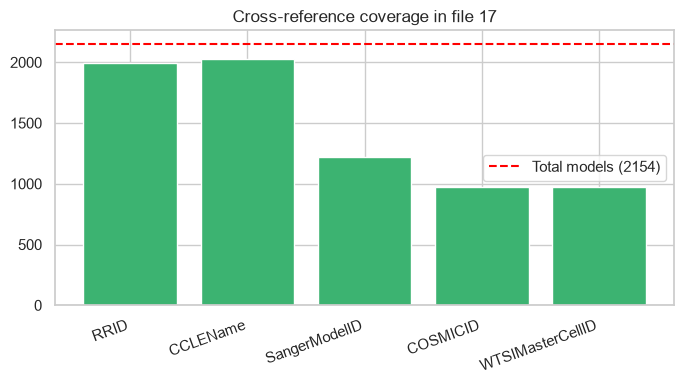

In [5]:
xref_cols = ['RRID', 'CCLEName', 'SangerModelID', 'COSMICID', 'WTSIMasterCellID']
coverage = {c: df[c].notna().sum() for c in xref_cols}
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(coverage.keys(), coverage.values(), color='mediumseagreen')
ax.axhline(len(df), color='red', linestyle='--', label=f'Total models ({len(df)})')
ax.set_title('Cross-reference coverage in file 17'); ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

### Why this EDA check matters

`RRID` completeness here determines how many of the 286 orphan models (and the rest of the modern
set) can still reach Cellosaurus (notebook 07) and the rest of the identity bridge, even though
they are invisible to file 9's legacy schema.

## Decisions carried into the next notebooks

1. **File 17 is the reconciliation table between file 9's legacy schema and files 5/8/15/16's
   modern schema** — `preprocess.py`'s identity spine must be built from the union of both,
   not file 9 alone, or the measured orphan count from §2 is silently dropped.
2. The measured orphan count from §2 should replace the "286" figure wherever it is cited, if it
   differs.
3. Legacy `lineage` and modern `OncotreeLineage` are **not a clean 1:1 remap** for every category
   (§3) — any code that stratifies by lineage must pick one taxonomy consistently, not mix the two.
4. `RRID` coverage here (§4) extends Cellosaurus bridging to models file 9 cannot describe.
5. **Limitation:** the lineage crosstab in §3 is limited to the top legacy categories by count for
   readability — a full reconciliation table belongs in `preprocessing/` when the identity spine
   is actually built, not fully enumerated here.